In [5]:
import numpy as np
import pycalphad.model as pype
from pycalphad.model import RWModelE,autoH,CSModelE,SRModelE,autoS,autoG, pe_dict, RTDB_globals, Define_Element
from espei import pureElement as pe
from espei.pureElement import imp_data_PE, Cp_fit, pe_inputJSON,pe_def_model, pe_iGuess
from matplotlib import pylab as plt

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pydantic\_migration.py:283: UserWarning: `pydantic:PyObject` has been moved to `pydantic.types:ImportString`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


In [2]:
from pycalphad import Database, calculate, equilibrium, variables as v
db_sgte = Database('sgte-unary.tdb')

c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\io\tdb.py:925: UserWarning: The type definition character `I` was defined in the following phases: ['CBCC_A12', 'BCC_A2', 'FCC_A1', 'HCP_A3'], but no corresponding TYPE_DEFINITION line was found in the TDB.
  warnings.warn(f"The type definition character `{typechar}` was defined in the following phases: "


In [3]:
#personal replotting of Cp for elements

# CR

In [4]:
#Clears dictionary
dict.fromkeys(RTDB_globals, None)
print('clean')

clean


In [5]:
Define_Element(['CR'])
dataset=imp_data_PE("CR_CP.json")
T_range = np.linspace(1,dataset.Temp.max()*1.1,num=200)

In [6]:
initialGuessSR=[300, -0.009, 0, 1400, 100]
initialGuessRW=[300, 1e-3, 1e-6]

In [7]:
parmNamesSR = ['Theta_E','beta1','beta2','tau','gamma']
fit_paramsSRE = Cp_fit(SRModelE, initialGuess=initialGuessSR, parmNames=parmNamesSR, data_df=dataset)
CpResSre = SRModelE(T_range, *fit_paramsSRE)
SRE = fit_paramsSRE[0]
RTDB_globals['k1_final'] = fit_paramsSRE[1]
RTDB_globals['k2_final'] = fit_paramsSRE[2]
RTDB_globals['alfa_final'] = fit_paramsSRE[3]
RTDB_globals['g_final'] = fit_paramsSRE[4]


Non-linear least squares
Model: SRModelE

            Estimate     StdErr        tval          pval
Theta_E   356.448701   3.419247  104.247716  0.000000e+00
beta1       0.004779   0.000277   17.258996  0.000000e+00
beta2       0.020102   0.002282    8.810826  0.000000e+00
tau      1034.909420  59.351001   17.437101  0.000000e+00
gamma     441.572500  86.569095    5.100810  5.325645e-07

Residual Standard Error:  0.9726
Df: 384
AIC: 1142.577436054362
CHECKPOINT AICC CALLED
k= 5 n= 389
aic2: -16.643257221126674
correction:  0.1566579634464752
CHECKPOINT AICC SOLVED
AICC: -16.4865992576802


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1694: RuntimeWarning: overflow encountered in scalar power
  f1 = np.exp(Theta_E/i)/(np.exp(Theta_E/i)-1)**2.0


In [8]:
parmNamesRW = ['ThetaE','a','b']
fit_paramsRW = Cp_fit(RWModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResRW = RWModelE(T_range, *fit_paramsRW)
RWE = fit_paramsRW[0]
RWa=fit_paramsRW[1]
RWb=fit_paramsRW[2]


Non-linear least squares
Model: RWModelE

          Estimate        StdErr        tval    pval
ThetaE  338.344210  3.281045e+00  103.120857  0.0000
a         0.000747  3.052741e-04    2.448237  0.0148
b         0.000007  2.437029e-07   27.031029  0.0000

Residual Standard Error:  1.0452
Df: 386
AIC: 1080.562474069727
CHECKPOINT AICC CALLED
k= 3 n= 389
aic2: 37.37170476350825
correction:  0.06233766233766234
CHECKPOINT AICC SOLVED
AICC: 37.43404242584591


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


In [9]:
fit_paramsCS = Cp_fit(CSModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResCS = CSModelE(T_range, *fit_paramsCS)
CSa=fit_paramsCS[1]
CSb=fit_paramsCS[2]
CSE=fit_paramsCS[0]

Non-linear least squares
Model: CSModelE

            Estimate        StdErr        tval  pval
ThetaE  3.598969e+02  2.972880e+00  121.060015   0.0
a       5.140131e-03  1.518294e-04   33.854648   0.0
b       1.642372e-12  5.820753e-14   28.215809   0.0

Residual Standard Error:  1.0042
Df: 386
AIC: 1111.6594612815595
CHECKPOINT AICC CALLED
k= 3 n= 389
aic2: 6.274717551675823
correction:  0.06233766233766234
CHECKPOINT AICC SOLVED
AICC: 6.3370552140134855


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1637: RuntimeWarning: overflow encountered in square
  Cv_E = koef * (Te / T) ** 2 * np.exp(Te / T) / (np.exp(Te / T) - 1) ** 2


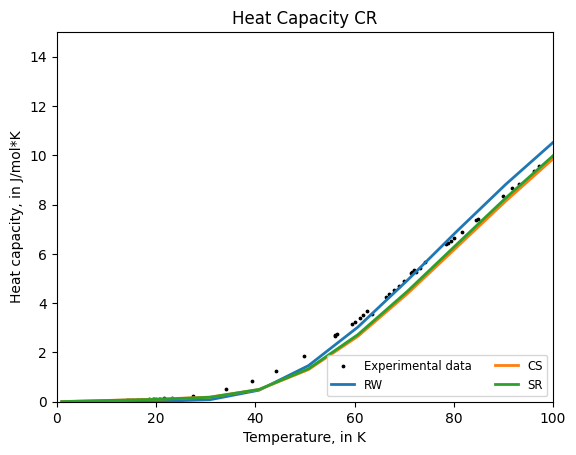

In [10]:
plt.scatter(dataset.Temp, dataset.Cp, color='k', s=3)
plt.plot(T_range,CpResRW,linewidth=2)
plt.plot(T_range,CpResCS,linewidth=2)
plt.plot(T_range, CpResSre,linewidth=2)
plt.xlim(0,100)
plt.ylim(0,15)
plt.xlabel("Temperature, in K")
plt.ylabel("Heat capacity, in J/mol*K")
plt.legend(['Experimental data','RW','CS','SR'],ncol=2, fontsize='small', loc='lower right')
plt.title('Heat Capacity '+ RTDB_globals['element'][0])
plt.show()

-91.41613707040327 <class 'numpy.ndarray'> 200
0.000750677044073353 <class 'numpy.ndarray'> 200
sr


Text(0.5, 1.0, 'Gibbs CR')

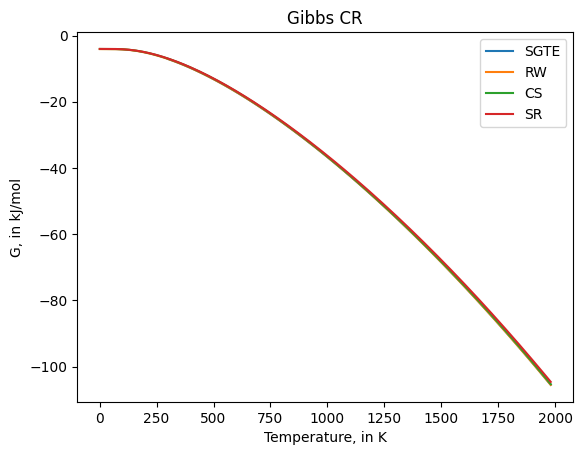

In [11]:
fcc_GM = calculate(db_sgte, ['CR', 'VA'], 'BCC_A2', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='SGTE')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(RWE,T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
plt.plot(T_range,GSR/1000, label = 'SR')
plt.xlabel("Temperature, in K")
plt.ylabel("G, in kJ/mol")
plt.legend()
plt.title("Gibbs "+ RTDB_globals['element'][0])

In [13]:
print(RTDB_globals['p'],RTDB_globals['bta'],RTDB_globals['Tc'])


0 0.008 311.5


# MO

In [206]:
#Clears dictionary
dict.fromkeys(RTDB_globals, None)
print('clean')

clean


In [207]:
Define_Element(['MO'])
dataset=imp_data_PE("MO_CP.json")
T_range = np.linspace(1,dataset.Temp.max()*1.1,num=800)

In [208]:
initialGuessSR=[300, 0, 0, 750, 200]
initialGuessRW=[490, 1e-3, 1e-6]

In [209]:
parmNamesSR = ['Theta_E','beta1','beta2','tau','gamma']
fit_paramsSRE = Cp_fit(SRModelE, initialGuess=initialGuessSR, parmNames=parmNamesSR, data_df=dataset)
CpResSre = SRModelE(T_range, *fit_paramsSRE)
SRE = fit_paramsSRE[0]
RTDB_globals['k1_final'] = fit_paramsSRE[1]
RTDB_globals['k2_final'] = fit_paramsSRE[2]
RTDB_globals['alfa_final'] = fit_paramsSRE[3]
RTDB_globals['g_final'] = fit_paramsSRE[4]


Non-linear least squares
Model: SRModelE

            Estimate        StdErr        tval      pval
Theta_E   295.053913  2.628059e+00  112.270662  0.000000
beta1      -0.004815  2.861555e-04  -16.825282  0.000000
beta2       0.030153  7.739921e+02    0.000039  0.999969
tau      1783.846749  6.039036e+07    0.000030  0.999976
gamma    2352.689302  6.039036e+07    0.000039  0.999969

Residual Standard Error:  0.8661
Df: 1633
AIC: 5136.468385940561
CHECKPOINT AICC CALLED
k= 5 n= 1638
aic2: -466.0257511620539
correction:  0.03676470588235294
CHECKPOINT AICC SOLVED
AICC: -465.9889864561715


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


In [210]:
parmNamesRW = ['ThetaE','a','b']
fit_paramsRW = Cp_fit(RWModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResRW = RWModelE(T_range, *fit_paramsRW)
RWE = fit_paramsRW[0]
RWa=fit_paramsRW[1]
RWb=fit_paramsRW[2]


Non-linear least squares
Model: RWModelE

          Estimate        StdErr        tval      pval
ThetaE  271.967717  1.725139e+00  157.649734  0.000000
a         0.000106  6.778792e-05    1.560260  0.118892
b         0.000003  3.067439e-08   92.842875  0.000000

Residual Standard Error:  0.9031
Df: 1635
AIC: 4993.414551868589
CHECKPOINT AICC CALLED
k= 3 n= 1638
aic2: -330.9719170900813
correction:  0.014687882496940025
CHECKPOINT AICC SOLVED
AICC: -330.95722920758436


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


In [211]:
fit_paramsCS = Cp_fit(CSModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResCS = CSModelE(T_range, *fit_paramsCS)
CSa=fit_paramsCS[1]
CSb=fit_paramsCS[2]
CSE=fit_paramsCS[0]

c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


Non-linear least squares
Model: CSModelE

            Estimate        StdErr        tval  pval
ThetaE  2.851596e+02  1.490868e+00  191.270882   0.0
a       3.675325e-03  2.548447e-05  144.218225   0.0
b       2.324272e-13  2.059068e-15  112.879798   0.0

Residual Standard Error:  0.7620
Df: 1635
AIC: 5549.781015851249
CHECKPOINT AICC CALLED
k= 3 n= 1638
aic2: -887.338381072741
correction:  0.014687882496940025
CHECKPOINT AICC SOLVED
AICC: -887.3236931902441


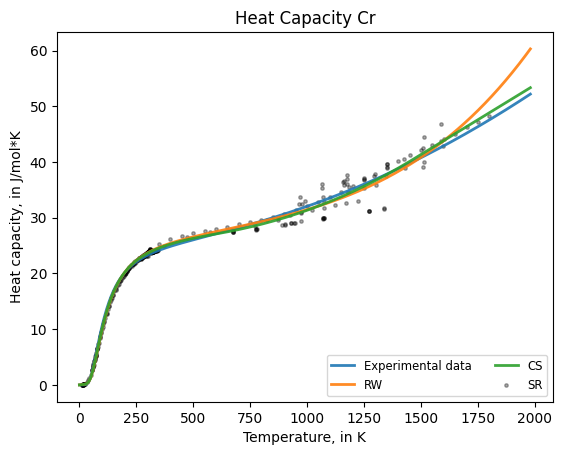

In [14]:
plt.plot(T_range,CpResRW,linewidth=2, alpha=0.9)
plt.plot(T_range,CpResCS,linewidth=2, alpha=0.9)
plt.plot(T_range, CpResSre,linewidth=2, alpha=0.9)
plt.scatter(dataset.Temp, dataset.Cp, color='k', s=6, alpha=0.33)
#plt.xlim(0,100)
#plt.ylim(0,15)
plt.xlabel("Temperature, in K")
plt.ylabel("Heat capacity, in J/mol*K")
plt.legend(['Experimental data','RW','CS','SR'],ncol=2, fontsize='small', loc='lower right')
plt.title('Heat Capacity '+ RTDB_globals['element'][0])
plt.show()

-29.86076370133851 <class 'numpy.ndarray'> 800
0.00010719071999440373 <class 'numpy.ndarray'> 800
sr


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1953: RuntimeWarning: invalid value encountered in log
  S = (alfa -g)**2.0*(3.0*k2/(8.0*g) - k2 *np.log(alfa-g)/(4*g))*x+(k1-k2*(alfa-g)/(2.0*g))*x**2+k2/(8.0*g)*x**3.0+k2/(4.0*g)*(alfa-g)**2.0*x*np.log(x)


Text(0.5, 1.0, 'Gibbs MO')

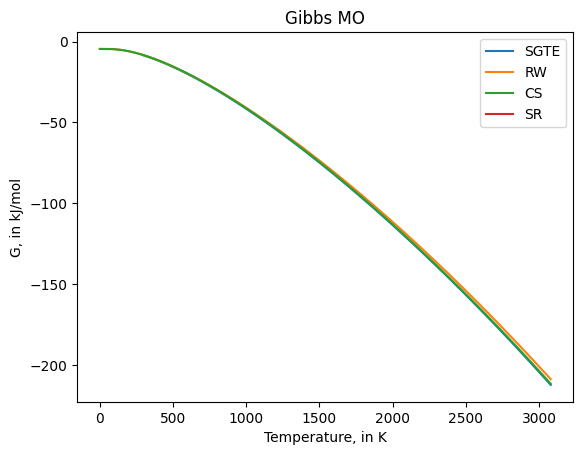

In [205]:
fcc_GM = calculate(db_sgte, ['MO', 'VA'], 'BCC_A2', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='SGTE')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(RWE,T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
plt.plot(T_range,GSR/1000, label = 'SR')
plt.xlabel("Temperature, in K")
plt.ylabel("G, in kJ/mol")
plt.legend()
plt.title("Gibbs "+ RTDB_globals['element'][0])

# NB

In [177]:
#Clears dictionary
dict.fromkeys(RTDB_globals, None)
print('clean')

clean


In [178]:
Define_Element(['NB'])
dataset=imp_data_PE("NB_CP.json")
T_range = np.linspace(1,dataset.Temp.max()*1.1,num=800)

In [179]:
initialGuessSR=[200, 1e5, 0, 650, 410]
initialGuessRW=[490, 1e-3, 1e-6]

In [180]:
parmNamesSR = ['Theta_E','beta1','beta2','tau','gamma']
fit_paramsSRE = Cp_fit(SRModelE, initialGuess=initialGuessSR, parmNames=parmNamesSR, data_df=dataset)
CpResSre = SRModelE(T_range, *fit_paramsSRE)
SRE = fit_paramsSRE[0]
RTDB_globals['k1_final'] = fit_paramsSRE[1]
RTDB_globals['k2_final'] = fit_paramsSRE[2]
RTDB_globals['alfa_final'] = fit_paramsSRE[3]
RTDB_globals['g_final'] = fit_paramsSRE[4]


Non-linear least squares
Model: SRModelE

            Estimate        StdErr       tval      pval
Theta_E   208.143874  2.885374e+00  72.137575  0.000000
beta1      -0.001801  4.930384e-04  -3.652135  0.000320
beta2       0.015291  2.879367e+03   0.000005  0.999996
tau      1120.956857  2.803453e+08   0.000004  0.999997
gamma    1488.788163  2.803453e+08   0.000005  0.999996

Residual Standard Error:  0.8552
Df: 237
AIC: 779.514991773403
CHECKPOINT AICC CALLED
k= 5 n= 242
aic2: -70.74874170234149
correction:  0.2542372881355932
CHECKPOINT AICC SOLVED
AICC: -70.49450441420589


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


In [181]:
parmNamesRW = ['ThetaE','a','b']
fit_paramsRW = Cp_fit(RWModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResRW = RWModelE(T_range, *fit_paramsRW)
RWE = fit_paramsRW[0]
RWa=fit_paramsRW[1]
RWb=fit_paramsRW[2]


Non-linear least squares
Model: RWModelE

          Estimate        StdErr       tval      pval
ThetaE  201.950563  2.541759e+00  79.453061  0.000000
a         0.000685  2.546710e-04   2.688965  0.007672
b         0.000002  1.371431e-07  17.194328  0.000000

Residual Standard Error:  0.8813
Df: 239
AIC: 758.9612484820366
CHECKPOINT AICC CALLED
k= 3 n= 242
aic2: -58.19499841097492
correction:  0.10084033613445378
CHECKPOINT AICC SOLVED
AICC: -58.094158074840465


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


In [182]:
fit_paramsCS = Cp_fit(CSModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResCS = CSModelE(T_range, *fit_paramsCS)
CSa=fit_paramsCS[1]
CSb=fit_paramsCS[2]
CSE=fit_paramsCS[0]

Non-linear least squares
Model: CSModelE

            Estimate        StdErr       tval  pval
ThetaE  2.075965e+02  2.535211e+00  81.885300   0.0
a       3.210253e-03  1.197241e-04  26.813759   0.0
b       2.424276e-13  1.408907e-14  17.206780   0.0

Residual Standard Error:  0.8797
Df: 239
AIC: 759.799726386293
CHECKPOINT AICC CALLED
k= 3 n= 242
aic2: -59.03347631523134
correction:  0.10084033613445378
CHECKPOINT AICC SOLVED
AICC: -58.93263597909689


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


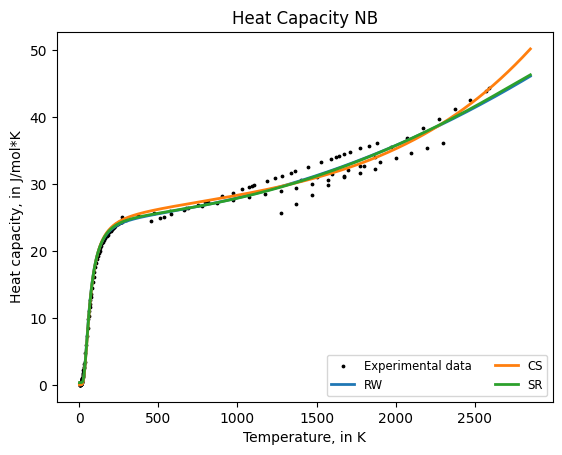

In [183]:
plt.scatter(dataset.Temp, dataset.Cp, color='k', s=3)
plt.plot(T_range,CpResRW,linewidth=2)
plt.plot(T_range,CpResCS,linewidth=2)
plt.plot(T_range, CpResSre,linewidth=2)
#plt.xlim(0,100)
#plt.ylim(0,15)
plt.xlabel("Temperature, in K")
plt.ylabel("Heat capacity, in J/mol*K")
plt.legend(['Experimental data','RW','CS','SR'],ncol=2, fontsize='small', loc='lower right')
plt.title('Heat Capacity '+ RTDB_globals['element'][0])
plt.show()

-51.269360528187725 <class 'numpy.ndarray'> 800
0.0006859803141204654 <class 'numpy.ndarray'> 800
sr


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1953: RuntimeWarning: invalid value encountered in log
  S = (alfa -g)**2.0*(3.0*k2/(8.0*g) - k2 *np.log(alfa-g)/(4*g))*x+(k1-k2*(alfa-g)/(2.0*g))*x**2+k2/(8.0*g)*x**3.0+k2/(4.0*g)*(alfa-g)**2.0*x*np.log(x)
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1955: RuntimeWarning: invalid value encountered in log
  S = (-3.0*k2*alfa/2 - k2/(4.0*g)*((alfa-g)**2 * np.log(alfa-g)-(alfa+g)**2*np.log(alfa+g)))*x+(k1+k2)*x**2-k2*alfa*x*np.log(x)


Text(0.5, 1.0, 'Gibbs NB')

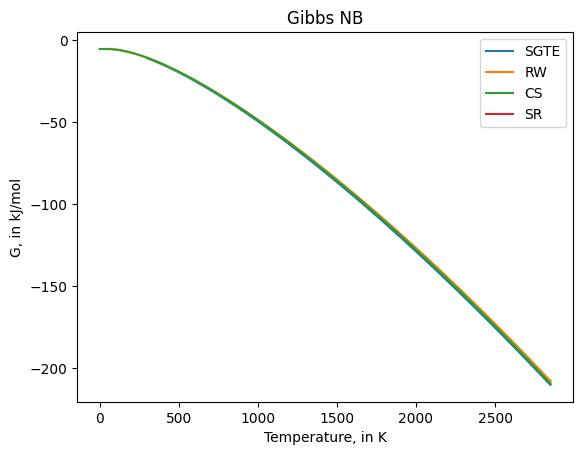

In [185]:
fcc_GM = calculate(db_sgte, ['NB', 'VA'], 'BCC_A2', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='SGTE')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(RWE,T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
plt.plot(T_range,GSR/1000, label = 'SR')
plt.xlabel("Temperature, in K")
plt.ylabel("G, in kJ/mol")
plt.legend()
plt.title("Gibbs "+ RTDB_globals['element'][0])

# Cu

In [160]:
#Clears dictionary
dict.fromkeys(RTDB_globals, None)
print('clean')

clean


In [161]:
Define_Element(['CU'])
dataset=imp_data_PE("CU_CP.json")
T_range = np.linspace(1,dataset.Temp.max()*1.1,num=800)

In [162]:
initialGuessSR=[200, 0, 0, 1000, 210]
initialGuessRW=[490, 1e-3, 1e-6]

In [163]:
parmNamesSR = ['Theta_E','beta1','beta2','tau','gamma']
fit_paramsSRE = Cp_fit(SRModelE, initialGuess=initialGuessSR, parmNames=parmNamesSR, data_df=dataset)
CpResSre = SRModelE(T_range, *fit_paramsSRE)
SRE = fit_paramsSRE[0]
RTDB_globals['k1_final'] = fit_paramsSRE[1]
RTDB_globals['k2_final'] = fit_paramsSRE[2]
RTDB_globals['alfa_final'] = fit_paramsSRE[3]
RTDB_globals['g_final'] = fit_paramsSRE[4]


Non-linear least squares
Model: SRModelE

           Estimate      StdErr        tval          pval
Theta_E  234.880671    0.590251  397.933415  0.000000e+00
beta1      0.003942    0.000043   91.992961  0.000000e+00
beta2      0.003767    0.000692    5.445357  5.761325e-08
tau      904.876195   61.118856   14.805189  0.000000e+00
gamma     93.646316  154.540759    0.605965  5.446020e-01

Residual Standard Error:  0.6097
Df: 2146
AIC: 8250.154359505355
CHECKPOINT AICC CALLED
k= 5 n= 2151
aic2: -2123.8807896588546
correction:  0.027972027972027972
CHECKPOINT AICC SOLVED
AICC: -2123.852817630883


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


In [164]:
parmNamesRW = ['ThetaE','a','b']
fit_paramsRW = Cp_fit(RWModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResRW = RWModelE(T_range, *fit_paramsRW)
RWE = fit_paramsRW[0]
RWa=fit_paramsRW[1]
RWb=fit_paramsRW[2]


Non-linear least squares
Model: RWModelE

          Estimate        StdErr        tval  pval
ThetaE  232.443201  5.982205e-01  388.557725   0.0
a         0.002814  9.364819e-05   30.052484   0.0
b         0.000002  1.172011e-07   15.078220   0.0

Residual Standard Error:  0.5966
Df: 2148
AIC: 8337.27400814579
CHECKPOINT AICC CALLED
k= 3 n= 2151
aic2: -2219.000438299289
correction:  0.011178388448998603
CHECKPOINT AICC SOLVED
AICC: -2218.98925991084


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


In [165]:
fit_paramsCS = Cp_fit(CSModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResCS = CSModelE(T_range, *fit_paramsCS)
CSa=fit_paramsCS[1]
CSb=fit_paramsCS[2]
CSE=fit_paramsCS[0]

Non-linear least squares
Model: CSModelE

            Estimate        StdErr        tval  pval
ThetaE  2.343373e+02  5.882515e-01  398.362391   0.0
a       3.765040e-03  4.626232e-05   81.384590   0.0
b       5.886068e-13  4.841816e-14   12.156736   0.0

Residual Standard Error:  0.6066
Df: 2148
AIC: 8265.739934000538
CHECKPOINT AICC CALLED
k= 3 n= 2151
aic2: -2147.466364154036
correction:  0.011178388448998603
CHECKPOINT AICC SOLVED
AICC: -2147.455185765587


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


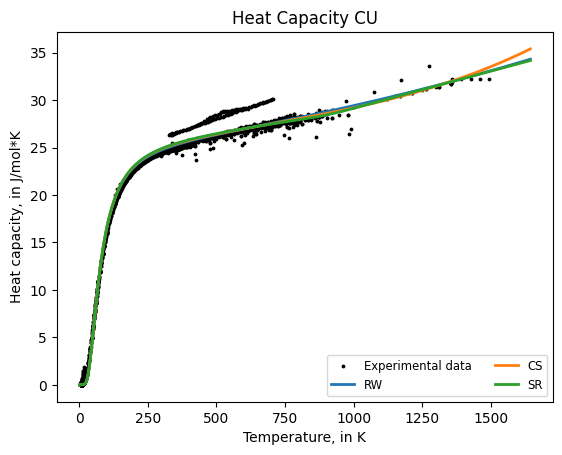

In [166]:
plt.scatter(dataset.Temp, dataset.Cp, color='k', s=3)
plt.plot(T_range,CpResRW,linewidth=2)
plt.plot(T_range,CpResCS,linewidth=2)
plt.plot(T_range, CpResSre,linewidth=2)
#plt.xlim(0,100)
#plt.ylim(0,15)
plt.xlabel("Temperature, in K")
plt.ylabel("Heat capacity, in J/mol*K")
plt.legend(['Experimental data','RW','CS','SR'],ncol=2, fontsize='small', loc='lower right')
plt.title('Heat Capacity '+ RTDB_globals['element'][0])
plt.show()

-140.6999025906071 <class 'numpy.ndarray'> 800
0.0028152443914239793 <class 'numpy.ndarray'> 800
sr


Text(0.5, 1.0, 'Gibbs CU')

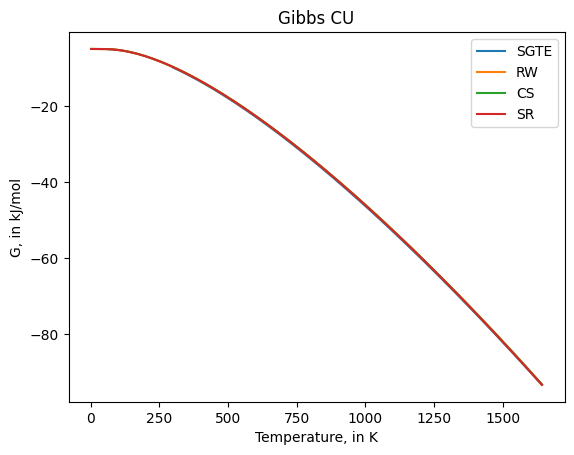

In [167]:
fcc_GM = calculate(db_sgte, ['CU', 'VA'], 'FCC_A1', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='SGTE')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(RWE,T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
plt.plot(T_range,GSR/1000, label = 'SR')
plt.xlabel("Temperature, in K")
plt.ylabel("G, in kJ/mol")
plt.legend()
plt.title("Gibbs "+ RTDB_globals['element'][0])

# Al


In [104]:
#Clears dictionary
dict.fromkeys(RTDB_globals, None)
print('clean')

clean


In [105]:
Define_Element(['AL'])
dataset=imp_data_PE("AL_CP2.json")
T_range = np.linspace(1,dataset.Temp.max()*1.1,num=800)

In [106]:
initialGuessSR=[400, 1e5, 0, 650, 410]
initialGuessRW=[490, 1e-3, 1e-6]

In [107]:
parmNamesSR = ['Theta_E','beta1','beta2','tau','gamma']
fit_paramsSRE = Cp_fit(SRModelE, initialGuess=initialGuessSR, parmNames=parmNamesSR, data_df=dataset)
CpResSre = SRModelE(T_range, *fit_paramsSRE)
SRE = fit_paramsSRE[0]
RTDB_globals['k1_final'] = fit_paramsSRE[1]
RTDB_globals['k2_final'] = fit_paramsSRE[2]
RTDB_globals['alfa_final'] = fit_paramsSRE[3]
RTDB_globals['g_final'] = fit_paramsSRE[4]


Non-linear least squares
Model: SRModelE

           Estimate        StdErr       tval      pval
Theta_E  288.366333  7.369071e+00  39.131981  0.000000
beta1      0.002792  6.388596e-03   0.437061  0.662375
beta2      0.013567  3.174865e+03   0.000004  0.999997
tau      560.626558  1.168424e+08   0.000005  0.999996
gamma    499.327508  1.168424e+08   0.000004  0.999997

Residual Standard Error:  0.8873
Df: 307
AIC: 977.0662760391474
CHECKPOINT AICC CALLED
k= 5 n= 312
aic2: -69.64863131943153
correction:  0.19607843137254902
CHECKPOINT AICC SOLVED
AICC: -69.45255288805897


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


In [108]:
parmNamesRW = ['ThetaE','a','b']
fit_paramsRW = Cp_fit(RWModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResRW = RWModelE(T_range, *fit_paramsRW)
RWE = fit_paramsRW[0]
RWa=fit_paramsRW[1]
RWb=fit_paramsRW[2]


Non-linear least squares
Model: RWModelE

          Estimate        StdErr        tval          pval
ThetaE  287.986467  2.348131e+00  122.644978  0.000000e+00
a         0.002051  5.407053e-04    3.793336  1.787957e-04
b         0.000007  8.691540e-07    7.721886  1.607603e-13

Residual Standard Error:  0.8847
Df: 309
AIC: 972.8500282042135
CHECKPOINT AICC CALLED
k= 3 n= 312
aic2: -73.43238348449788
correction:  0.07792207792207792
CHECKPOINT AICC SOLVED
AICC: -73.3544614065758


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


In [109]:
fit_paramsCS = Cp_fit(CSModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResCS = CSModelE(T_range, *fit_paramsCS)
CSa=fit_paramsCS[1]
CSb=fit_paramsCS[2]
CSE=fit_paramsCS[0]

Non-linear least squares
Model: CSModelE

            Estimate        StdErr        tval          pval
ThetaE  2.944909e+02  2.200589e+00  133.823647  0.000000e+00
a       5.002202e-03  2.481935e-04   20.154446  0.000000e+00
b       4.132811e-12  7.472436e-13    5.530742  6.798562e-08

Residual Standard Error:  0.9198
Df: 309
AIC: 948.6090936083573
CHECKPOINT AICC CALLED
k= 3 n= 312
aic2: -49.191448888641645
correction:  0.07792207792207792
CHECKPOINT AICC SOLVED
AICC: -49.11352681071957


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


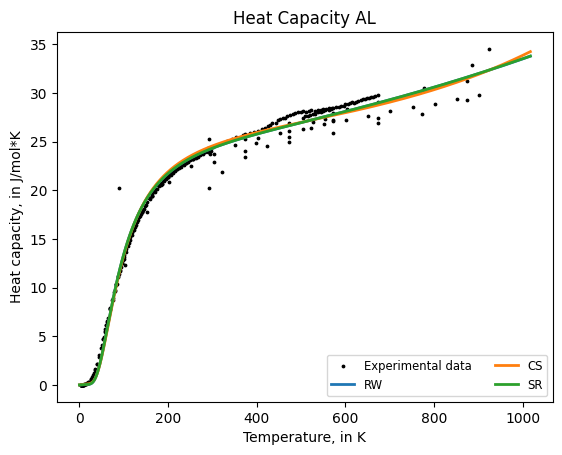

In [110]:
plt.scatter(dataset.Temp, dataset.Cp, color='k', s=3)
plt.plot(T_range,CpResRW,linewidth=2)
plt.plot(T_range,CpResCS,linewidth=2)
plt.plot(T_range, CpResSre,linewidth=2)
#plt.xlim(0,100)
#plt.ylim(0,15)
plt.xlabel("Temperature, in K")
plt.ylabel("Heat capacity, in J/mol*K")
plt.legend(['Experimental data','RW','CS','SR'],ncol=2, fontsize='small', loc='lower right')
plt.title('Heat Capacity '+ RTDB_globals['element'][0])
plt.show()

-150.455578862801 <class 'numpy.ndarray'> 800
0.002054432680260609 <class 'numpy.ndarray'> 800
sr


Text(0.5, 1.0, 'Gibbs AL')

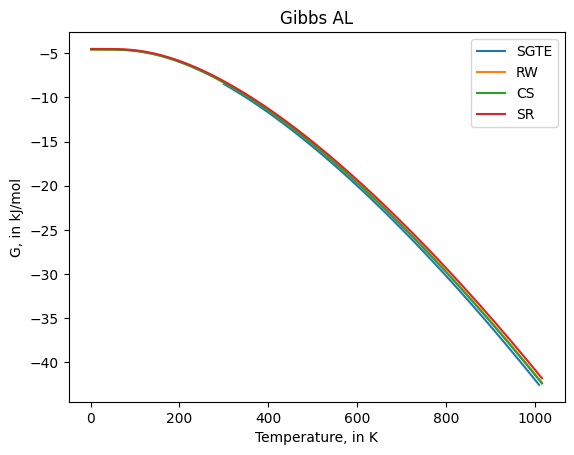

In [111]:
fcc_GM = calculate(db_sgte, ['AL', 'VA'], 'FCC_A1', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='SGTE')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(RWE,T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
plt.plot(T_range,GSR/1000, label = 'SR')
plt.xlabel("Temperature, in K")
plt.ylabel("G, in kJ/mol")
plt.legend()
plt.title("Gibbs "+ RTDB_globals['element'][0])

# Ni

In [131]:
#Clears dictionary
a=dict.fromkeys(RTDB_globals, None)
print('clean')

clean


In [132]:
Define_Element(['NI'])
dataset=imp_data_PE("NI_CP.json")
T_range = np.arange(0.15,dataset.Temp.max()*1.1,2)

In [153]:
initialGuessSR=[200, 1e5, 0, 1500, 810]
initialGuessRW=[490, 1e-3, 1e-6]

In [154]:
parmNamesSR = ['Theta_E','beta1','beta2','tau','gamma']
fit_paramsSRE = Cp_fit(SRModelE, initialGuess=initialGuessSR, parmNames=parmNamesSR, data_df=dataset)
CpResSre = SRModelE(T_range, *fit_paramsSRE)
SRE = fit_paramsSRE[0]
RTDB_globals['k1_final'] = fit_paramsSRE[1]
RTDB_globals['k2_final'] = fit_paramsSRE[2]
RTDB_globals['alfa_final'] = fit_paramsSRE[3]
RTDB_globals['g_final'] = fit_paramsSRE[4]


Non-linear least squares
Model: SRModelE

            Estimate        StdErr       tval      pval
Theta_E   277.542212  3.827398e+00  72.514597  0.000000
beta1       0.004839  3.605504e-04  13.422260  0.000000
beta2       0.015428  2.123928e+03   0.000007  0.999994
tau      1292.792882  1.296595e+08   0.000010  0.999992
gamma     941.846664  1.296595e+08   0.000007  0.999994

Residual Standard Error:  1.2851
Df: 770
AIC: 1827.5958875077513
CHECKPOINT AICC CALLED
k= 5 n= 775
aic2: 393.75883895949147
correction:  0.07802340702210664
CHECKPOINT AICC SOLVED
AICC: 393.83686236651357


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1721: RuntimeWarning: overflow encountered in exp
  f1 = np.exp(Theta_E/i)/(np.exp(Theta_E/i)-1)**2.0
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1721: RuntimeWarning: invalid value encountered in scalar divide
  f1 = np.exp(Theta_E/i)/(np.exp(Theta_E/i)-1)**2.0


In [155]:
parmNamesRW = ['ThetaE','a','b']
fit_paramsRW = Cp_fit(RWModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResRW = RWModelE(T_range, *fit_paramsRW)
RWE = fit_paramsRW[0]
RWa=fit_paramsRW[1]
RWb=fit_paramsRW[2]


Non-linear least squares
Model: RWModelE

          Estimate        StdErr       tval  pval
ThetaE  273.514257  3.512889e+00  77.860207   0.0
a         0.003231  2.221818e-04  14.543846   0.0
b         0.000003  2.338750e-07  14.500605   0.0

Residual Standard Error:  1.2867
Df: 772
AIC: 1819.6137610029514
CHECKPOINT AICC CALLED
k= 3 n= 775
aic2: 393.74096546429126
correction:  0.0311284046692607
CHECKPOINT AICC SOLVED
AICC: 393.77209386896055


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1637: RuntimeWarning: overflow encountered in exp
  Cv_E = koef * (Te / T) ** 2 * np.exp(Te / T) / (np.exp(Te / T) - 1) ** 2
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1637: RuntimeWarning: invalid value encountered in divide
  Cv_E = koef * (Te / T) ** 2 * np.exp(Te / T) / (np.exp(Te / T) - 1) ** 2


In [156]:
fit_paramsCS = Cp_fit(CSModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResCS = CSModelE(T_range, *fit_paramsCS)
CSa=fit_paramsCS[1]
CSb=fit_paramsCS[2]
CSE=fit_paramsCS[0]

Non-linear least squares
Model: CSModelE

            Estimate        StdErr       tval  pval
ThetaE  2.815338e+02  3.595898e+00  78.293041   0.0
a       5.374748e-03  1.102137e-04  48.766618   0.0
b       8.828346e-13  7.614374e-14  11.594317   0.0

Residual Standard Error:  1.3389
Df: 772
AIC: 1757.9962650990665
CHECKPOINT AICC CALLED
k= 3 n= 775
aic2: 455.3584613681763
correction:  0.0311284046692607
CHECKPOINT AICC SOLVED
AICC: 455.38958977284557


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1637: RuntimeWarning: overflow encountered in exp
  Cv_E = koef * (Te / T) ** 2 * np.exp(Te / T) / (np.exp(Te / T) - 1) ** 2
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1637: RuntimeWarning: invalid value encountered in divide
  Cv_E = koef * (Te / T) ** 2 * np.exp(Te / T) / (np.exp(Te / T) - 1) ** 2


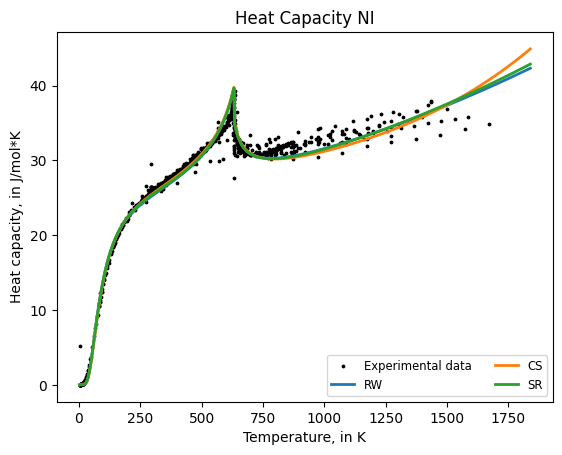

In [157]:
plt.scatter(dataset.Temp, dataset.Cp, color='k', s=3)
plt.plot(T_range,CpResRW,linewidth=2)
plt.plot(T_range,CpResCS,linewidth=2)
plt.plot(T_range, CpResSre,linewidth=2)
plt.xlabel("Temperature, in K")
plt.ylabel("Heat capacity, in J/mol*K")
plt.legend(['Experimental data','RW','CS','SR'],ncol=2, fontsize='small', loc='lower right')
plt.title('Heat Capacity '+ RTDB_globals['element'][0])
plt.show()

-173.58483873700996 <class 'numpy.ndarray'> 921
7.271171454353123e-05 <class 'numpy.ndarray'> 921
sr


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1869: RuntimeWarning: overflow encountered in exp
  Ge = koef*(x*np.log(np.exp(Te/x)-1)-Te) - HEin(Te, 298.15)


Text(0.5, 1.0, 'Gibbs NI')

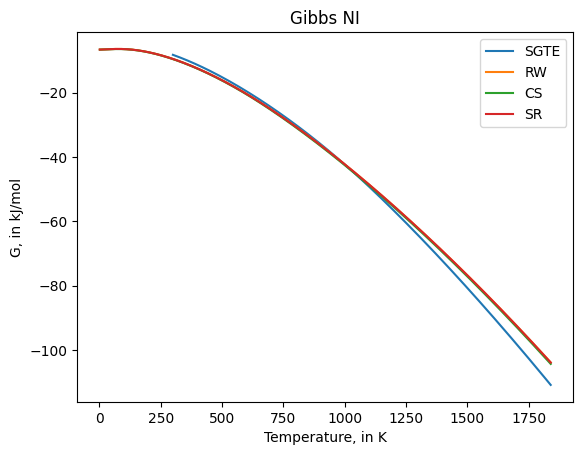

In [158]:
fcc_GM = calculate(db_sgte, ['FE', 'VA'], 'BCC_A2', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='SGTE')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(SRE,T_range)+pype.GibbsM_Bosse(T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)+pype.GibbsM_Bosse(T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
plt.plot(T_range,GSR/1000, label = 'SR')
plt.xlabel("Temperature, in K")
plt.ylabel("G, in kJ/mol")
plt.legend()
plt.title("Gibbs "+ RTDB_globals['element'][0])

# FE

In [112]:
#Clears dictionary
a=dict.fromkeys(RTDB_globals, None)
print('clean')

clean


In [113]:
Define_Element(['FE'])
dataset=imp_data_PE("FE_CP.json")
T_range = np.arange(0.15,dataset.Temp.max()*1.1,2)

In [114]:
initialGuessSR=[350, 0.008, 0.000, 1400, 100]
initialGuessRW=[490, 1e-3, 1e-6]

In [115]:
parmNamesSR = ['Theta_E','beta1','beta2','tau','gamma']
fit_paramsSRE = Cp_fit(SRModelE, initialGuess=initialGuessSR, parmNames=parmNamesSR, data_df=dataset)
CpResSre = SRModelE(T_range, *fit_paramsSRE)
SRE = fit_paramsSRE[0]
RTDB_globals['k1_final'] = fit_paramsSRE[1]
RTDB_globals['k2_final'] = fit_paramsSRE[2]
RTDB_globals['alfa_final'] = fit_paramsSRE[3]
RTDB_globals['g_final'] = fit_paramsSRE[4]


Non-linear least squares
Model: SRModelE

            Estimate      StdErr       tval      pval
Theta_E   307.882707   10.045819  30.647846  0.000000
beta1       0.007211    0.000212  34.028872  0.000000
beta2       0.012864    0.008462   1.520139  0.128897
tau      1487.729513  147.336833  10.097472  0.000000
gamma      96.930950  422.570342   0.229384  0.818633

Residual Standard Error:  4.4275
Df: 751
AIC: -87.16028767562466
CHECKPOINT AICC CALLED
k= 5 n= 756
aic2: 2254.5953498810895
correction:  0.08
CHECKPOINT AICC SOLVED
AICC: 2254.6753498810895


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1721: RuntimeWarning: overflow encountered in exp
  f1 = np.exp(Theta_E/i)/(np.exp(Theta_E/i)-1)**2.0
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1721: RuntimeWarning: invalid value encountered in scalar divide
  f1 = np.exp(Theta_E/i)/(np.exp(Theta_E/i)-1)**2.0


In [116]:
parmNamesRW = ['ThetaE','a','b']
fit_paramsRW = Cp_fit(RWModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResRW = RWModelE(T_range, *fit_paramsRW)
RWE = fit_paramsRW[0]
RWa=fit_paramsRW[1]
RWb=fit_paramsRW[2]


Non-linear least squares
Model: RWModelE

          Estimate        StdErr       tval      pval
ThetaE  303.523974  1.024913e+01  29.614621  0.000000
a         0.005902  6.463313e-04   9.131925  0.000000
b         0.000001  5.101697e-07   2.727674  0.006527

Residual Standard Error:  4.4474
Df: 753
AIC: -99.95468741403215
CHECKPOINT AICC CALLED
k= 3 n= 756
aic2: 2259.3897496194973
correction:  0.031914893617021274
CHECKPOINT AICC SOLVED
AICC: 2259.421664513114


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1637: RuntimeWarning: overflow encountered in exp
  Cv_E = koef * (Te / T) ** 2 * np.exp(Te / T) / (np.exp(Te / T) - 1) ** 2
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1637: RuntimeWarning: invalid value encountered in divide
  Cv_E = koef * (Te / T) ** 2 * np.exp(Te / T) / (np.exp(Te / T) - 1) ** 2


In [117]:
fit_paramsCS = Cp_fit(CSModelE, initialGuess=initialGuessRW, parmNames=parmNamesRW, data_df=dataset)
CpResCS = CSModelE(T_range, *fit_paramsCS)
CSa=fit_paramsCS[1]
CSb=fit_paramsCS[2]
CSE=fit_paramsCS[0]

c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\espei\pureElement.py:107: RuntimeWarning: invalid value encountered in sqrt
  parmSE = np.diag( np.sqrt( cov ) )


Non-linear least squares
Model: CSModelE

            Estimate        StdErr       tval      pval
ThetaE  3.060923e+02  1.007514e+01  30.380952  0.000000
a       6.839366e-03  2.895062e-04  23.624246  0.000000
b       3.392220e-13  1.028031e-13   3.299725  0.001013

Residual Standard Error:  4.4373
Df: 753
AIC: -96.52373674058401
CHECKPOINT AICC CALLED
k= 3 n= 756
aic2: 2255.9587989460492
correction:  0.031914893617021274
CHECKPOINT AICC SOLVED
AICC: 2255.990713839666


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1637: RuntimeWarning: overflow encountered in exp
  Cv_E = koef * (Te / T) ** 2 * np.exp(Te / T) / (np.exp(Te / T) - 1) ** 2
c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1637: RuntimeWarning: invalid value encountered in divide
  Cv_E = koef * (Te / T) ** 2 * np.exp(Te / T) / (np.exp(Te / T) - 1) ** 2


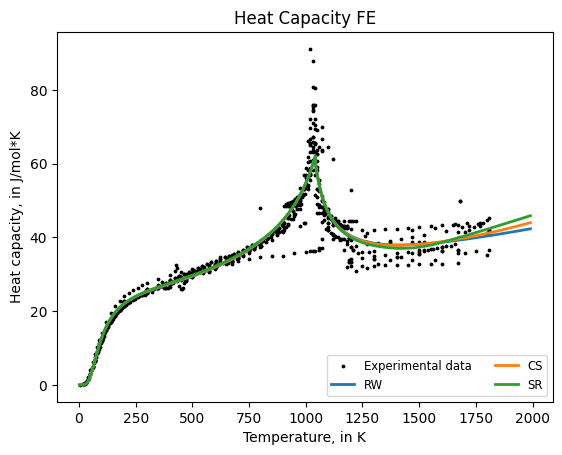

In [118]:
plt.scatter(dataset.Temp, dataset.Cp, color='k', s=3)
plt.plot(T_range,CpResRW,linewidth=2)
plt.plot(T_range,CpResCS,linewidth=2)
plt.plot(T_range, CpResSre,linewidth=2)
plt.xlabel("Temperature, in K")
plt.ylabel("Heat capacity, in J/mol*K")
plt.legend(['Experimental data','RW','CS','SR'],ncol=2, fontsize='small', loc='lower right')
plt.title('Heat Capacity '+ RTDB_globals['element'][0])
plt.show()

-274.6294006598806 <class 'numpy.ndarray'> 996
0.0001328029480821256 <class 'numpy.ndarray'> 996
sr


c:\Users\xander\anaconda3\envs\PESPEIv2\lib\site-packages\pycalphad\model.py:1869: RuntimeWarning: overflow encountered in exp
  Ge = koef*(x*np.log(np.exp(Te/x)-1)-Te) - HEin(Te, 298.15)


Text(0.5, 1.0, 'Gibbs FE')

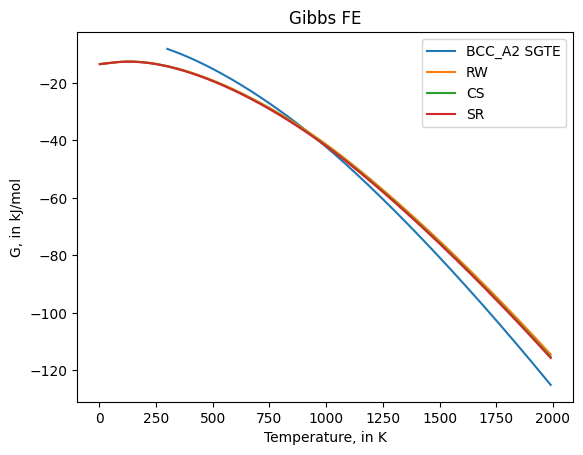

In [129]:
fcc_GM = calculate(db_sgte, ['FE', 'VA'], 'BCC_A2', P=101325, T=(300, max(T_range), 10), N=1)
bcc_GM = calculate(db_sgte, ['FE', 'VA'], 'BCC_A2', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='BCC_A2 SGTE')
#plt.plot(bcc_GM.T,bcc_GM.GM.squeeze()/1000, lavel='BCC_A2 SGTE')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(SRE,T_range)+pype.GibbsM_Bosse(T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)+pype.GibbsM_Bosse(T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
plt.plot(T_range,GSR/1000, label = 'SR')
plt.xlabel("Temperature, in K")
plt.ylabel("G, in kJ/mol")
plt.legend()
plt.title("Gibbs "+ RTDB_globals['element'][0])